# 03 — LP Optimization & Results

Goals:
- Define battery parameters
- Solve LP optimization for each day in the dataset
- Compare three scenarios: fixed tariff / dynamic no battery / dynamic + battery
- Visualize: price curve + charge/discharge schedule for a representative day
- Compute yearly savings in EUR

## 0. Imports & configuration

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

_nb_dir = Path(globals()['__vsc_ipynb_file__']).parent
_src    = (_nb_dir / '../src').resolve()
sys.path.insert(0, str(_src))

from battery_utils import optimize_day, threshold_strategy, backtest

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA = '../../Data/'

# ── Household consumption ──────────────────────────────────────────────────────
ANNUAL_KWH = 3500   # target annual consumption (kWh/year)
                    # 3500 = Belgian average household (Fluvius 2023)
                    # change to match your household before running backtests

# ── Battery parameters — BYD LFP 10 kWh ──────────────────────────────────────
battery = {
    "name":    "BYD LFP 10 kWh",
    "S_max":   10.0,   # total capacity (kWh)
    "S_min":    1.0,   # minimum SOC = 10% of capacity; protects against deep discharge
    "P_max":    5.0,   # max charge/discharge power (kW)
    "eta_c":    0.975, # charge efficiency (grid → battery)
    "eta_d":    0.975, # discharge efficiency (battery → load); eta_rt = eta_c * eta_d ≈ 0.95
    "S_init":   5.0,   # starting state of charge (50%)
    "deg_cost": 0.02,  # degradation cost EUR/kWh (NREL 2023, LFP residential)
}

S_MAX  = battery["S_max"]
S_MIN  = battery["S_min"]
P_MAX  = battery["P_max"]
ETA_C  = battery["eta_c"]
ETA_D  = battery["eta_d"]
S_INIT = battery["S_init"]
DEG    = battery["deg_cost"]

print(f"Household: {ANNUAL_KWH} kWh/year")
print(f"Battery  : {battery['name']}")
print(f"Capacity : {S_MAX} kWh  |  Min SOC: {S_MIN} kWh ({S_MIN/S_MAX:.0%})  |  Power: {P_MAX} kW")
print(f"η_charge : {ETA_C}  |  η_discharge: {ETA_D}  |  η_roundtrip: {ETA_C * ETA_D:.4f}")
print(f"Degradation: {DEG} EUR/kWh")
print(f"src path : {_src}")

Household: 3500 kWh/year
Battery  : BYD LFP 10 kWh
Capacity : 10.0 kWh  |  Min SOC: 1.0 kWh (10%)  |  Power: 5.0 kW
η_charge : 0.975  |  η_discharge: 0.975  |  η_roundtrip: 0.9506
Degradation: 0.02 EUR/kWh
src path : C:\Users\ummsa\DataScientist_Syntra\Stage\DinamischeTarief\battery-optimization-belgium\optimization\src


## 1. Load data

In [3]:
# ── Load cleaned data prepared by 02_eda.ipynb ────────────────────────────────
# Run 02_eda.ipynb first to generate Data/prepared/*.csv
PREPARED = '../../Data/prepared/'

prices = pd.read_csv(PREPARED + 'prices_clean.csv', index_col=0, parse_dates=True)
prices.index = prices.index.tz_convert('Europe/Brussels')

load = pd.read_csv(PREPARED + 'load_clean.csv', index_col=0, parse_dates=True)

print(f"Prices: {prices.index.min().date()} → {prices.index.max().date()}  ({len(prices):,} hrs)")
print(f"Load:   {load.index.min().date()} → {load.index.max().date()}  ({len(load):,} hrs)")

Prices: 2022-01-01 → 2025-12-30  (35,040 hrs)
Load:   2022-01-01 → 2025-12-30  (35,040 hrs)


## 1b. Load scaling — synthetic H0 → real kWh

Currently using the **H0 synthetic profile** (relative units, not real kWh).  
When real consumption data arrives → set `USE_REAL_LOAD = True` and provide the file path.

In [4]:
# ── Switch here when real data arrives ────────────────────────────────────────
USE_REAL_LOAD  = False
REAL_LOAD_PATH = '../../Data/real_consumption.csv'  # index=timestamp, col=consumption (kWh)

if USE_REAL_LOAD:
    # Real data: load as-is (already in kWh — no scaling needed)
    load = pd.read_csv(REAL_LOAD_PATH, index_col=0, parse_dates=True)
    load.columns = ['consumption']
    print(f"Mode: real data from {REAL_LOAD_PATH}")
else:
    # Synthetic H0: load_clean.csv was saved at 3500 kWh/year baseline in 02_eda.ipynb.
    # Rescale to ANNUAL_KWH so the results reflect the target household size.
    BASE_KWH = 3500
    if ANNUAL_KWH != BASE_KWH:
        load['consumption'] = load['consumption'] * (ANNUAL_KWH / BASE_KWH)
    print(f"Mode: synthetic H0 scaled to {ANNUAL_KWH} kWh/year")

actual = load[load.index.year == 2022]['consumption'].sum()
print(f"Annual total (2022): {actual:.0f} kWh")

Mode: synthetic H0 scaled to 3500 kWh/year
Annual total (2022): 3500 kWh


## 2. LP solver — single day

Baseline (no battery)             0.8731
                                      LP  Threshold
----------------------------------------------------
Grid bill (cost_electricity)      0.2477     0.3149
Battery wear (cost_degradation)    0.1124     0.1559
Net saving (saving_net)           0.5130     0.4023
Net saving (%)                     58.8%      46.1%


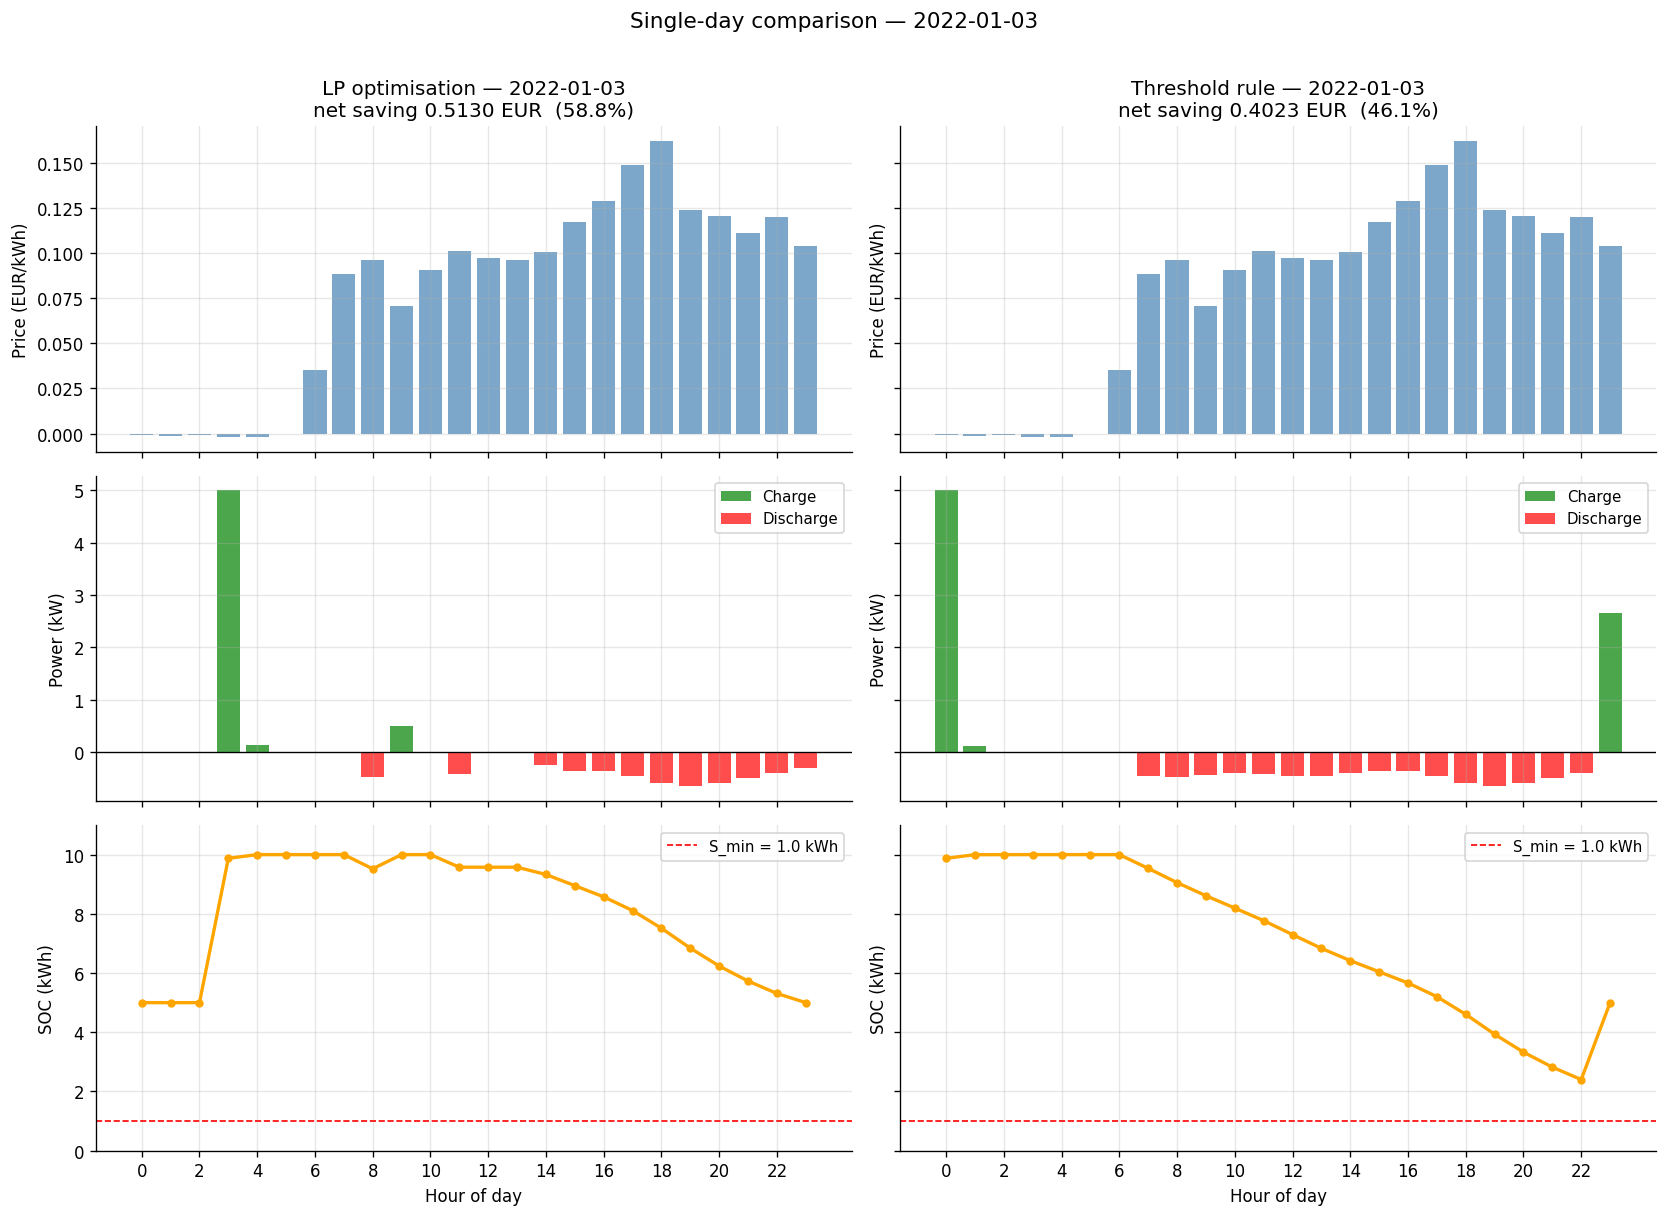

In [5]:
# ── Single-day demo: 2022-01-03 (a typical winter weekday) ───────────────────
demo_date = '2022-01-03'

p_day = prices[prices.index.date == pd.Timestamp(demo_date).date()]['price_eur_kwh'].values
l_day = load[load.index.date == pd.Timestamp(demo_date).date()]['consumption'].values

res_lp   = optimize_day(p_day, l_day, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT, cyclic=True, binary=True, deg_cost=DEG, S_min=S_MIN)
res_rule = threshold_strategy(p_day, l_day, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT, cyclic=True, deg_cost=DEG, S_min=S_MIN)
cost_base = float(np.dot(p_day, l_day))

print(f"{'Baseline (no battery)':30s}  {cost_base:8.4f}")
print(f"{'':30s}  {'LP':>8}  {'Threshold':>9}")
print("-" * 52)
print(f"{'Grid bill (cost_electricity)':30s}  {res_lp['cost_electricity']:8.4f}  {res_rule['cost_electricity']:9.4f}")
print(f"{'Battery wear (cost_degradation)':30s}  {res_lp['cost_degradation']:8.4f}  {res_rule['cost_degradation']:9.4f}")
print(f"{'Net saving (saving_net)':30s}  {cost_base - res_lp['cost']:8.4f}  {cost_base - res_rule['cost']:9.4f}")
print(f"{'Net saving (%)':30s}  {(cost_base - res_lp['cost'])/cost_base*100:7.1f}%  {(cost_base - res_rule['cost'])/cost_base*100:8.1f}%")

# ── Plot: LP (left) vs Threshold (right) ─────────────────────────────────────
hours = range(len(p_day))
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey='row')

for col, (res, title) in enumerate([(res_lp, 'LP optimisation'), (res_rule, 'Threshold rule')]):
    net_saving = cost_base - res['cost']

    # Row 0 — price
    axes[0, col].bar(hours, p_day, color='steelblue', alpha=0.7)
    axes[0, col].set_ylabel('Price (EUR/kWh)')
    axes[0, col].set_title(f'{title} — {demo_date}\nnet saving {net_saving:.4f} EUR  ({net_saving/cost_base*100:.1f}%)')

    # Row 1 — charge / discharge
    axes[1, col].bar(hours, res['c'], color='green', alpha=0.7, label='Charge')
    axes[1, col].bar(hours, [-x for x in res['d']], color='red', alpha=0.7, label='Discharge')
    axes[1, col].axhline(0, color='black', lw=0.8)
    axes[1, col].set_ylabel('Power (kW)')
    axes[1, col].legend(fontsize=9)

    # Row 2 — state of charge
    axes[2, col].plot(hours, res['s'], color='orange', lw=2, marker='o', ms=4)
    axes[2, col].axhline(S_MIN, color='red', lw=1, ls='--', label=f'S_min = {S_MIN} kWh')
    axes[2, col].set_ylabel('SOC (kWh)')
    axes[2, col].set_xlabel('Hour of day')
    axes[2, col].set_ylim(0, S_MAX + 1)
    axes[2, col].set_xticks(range(0, len(p_day), 2))
    axes[2, col].legend(fontsize=9)

plt.suptitle(f'Single-day comparison — {demo_date}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Backtesting — full dataset 2022–2025

In [29]:
# backtest() is defined in ../src/battery_utils.py and imported above

In [6]:
import time
from pathlib import Path

RECOMPUTE = True   # False → load saved CSV results and skip backtests

out_dir = Path('../results')
out_dir.mkdir(exist_ok=True)

if RECOMPUTE:
    # ── Run threshold strategy (fast — no LP) ─────────────────────────────────
    t0 = time.time()
    bt_rule = backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                       strategy='threshold', deg_cost=DEG, S_min=S_MIN)
    print(f"Threshold done: {len(bt_rule)} days  ({time.time()-t0:.1f}s)")

    # ── Run LP optimisation (slower — one LP per day) ─────────────────────────
    t0 = time.time()
    bt_lp = backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                     strategy='lp', deg_cost=DEG, S_min=S_MIN)
    print(f"LP done:        {len(bt_lp)} days  ({time.time()-t0:.1f}s)")

    bt_lp.to_csv(out_dir / 'backtest_lp.csv')
    bt_rule.to_csv(out_dir / 'backtest_threshold.csv')
    print(f"Saved to {out_dir.resolve()}")

else:
    bt_lp   = pd.read_csv(out_dir / 'backtest_lp.csv',        index_col=0, parse_dates=True)
    bt_rule = pd.read_csv(out_dir / 'backtest_threshold.csv', index_col=0, parse_dates=True)
    print(f"Loaded {len(bt_lp)} days from CSV")

Threshold done: 1460 days  (0.5s)
LP done:        1460 days  (46.9s)
Saved to C:\Users\ummsa\DataScientist_Syntra\Stage\DinamischeTarief\battery-optimization-belgium\optimization\results


## 3b. Binary vs plain LP — is the extra constraint worth it?

With `deg_cost > 0`, simultaneous charge+discharge is already suboptimal in the plain LP
(charging costs extra degradation for no gain), so the solver avoids it naturally.

This cell checks whether adding `binary=True` (MILP, slower) actually changes the results,
or whether `binary=False` (plain LP, faster) is sufficient — which matters for sensitivity analysis.

In [27]:
import time

# ── LP without binary constraint ──────────────────────────────────────────────
t0 = time.time()
bt_lp_plain = backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                       strategy='lp', binary=False, deg_cost=DEG, S_min=S_MIN)
t_plain = time.time() - t0

# ── LP with binary constraint (forbids simultaneous charge+discharge) ──────────
t0 = time.time()
bt_lp_binary = backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                        strategy='lp', binary=True, deg_cost=DEG, S_min=S_MIN)
t_binary = time.time() - t0

# ── Comparison table ──────────────────────────────────────────────────────────
# Note: with deg_cost > 0 the plain LP almost never produces simultaneous
# charge+discharge because it is always suboptimal (you pay degradation for nothing).
# The binary constraint is kept for robustness but has negligible effect on results.
print(f"{'':35s} {'Plain LP':>12}  {'Binary LP':>12}")
print("-" * 63)
print(f"{'Solver time (s)':35s} {t_plain:12.1f}  {t_binary:12.1f}")
print(f"{'Total cost 2022-2025 (EUR)':35s} {bt_lp_plain['cost'].sum():12.2f}  {bt_lp_binary['cost'].sum():12.2f}")
print(f"{'Total grid bill (EUR)':35s} {bt_lp_plain['cost_electricity'].sum():12.2f}  {bt_lp_binary['cost_electricity'].sum():12.2f}")
print(f"{'Total battery wear (EUR)':35s} {bt_lp_plain['cost_degradation'].sum():12.2f}  {bt_lp_binary['cost_degradation'].sum():12.2f}")
print(f"{'Net saving vs baseline (EUR)':35s} {bt_lp_plain['saving_net'].sum():12.2f}  {bt_lp_binary['saving_net'].sum():12.2f}")
diff = bt_lp_binary['saving_net'].sum() - bt_lp_plain['saving_net'].sum()
print(f"\nDifference in net saving: {diff:.2f} EUR over 4 years")

                                        Plain LP     Binary LP
---------------------------------------------------------------
Solver time (s)                             41.2          52.2
Total cost 2022-2025 (EUR)               1298.89       1298.77
Total grid bill (EUR)                    1138.24       1138.21
Total battery wear (EUR)                  160.64        160.57
Net saving vs baseline (EUR)              482.58        482.69

Difference in net saving: 0.11 EUR over 4 years


## 4. Compare scenarios

In [7]:
# ── Summary table: annual costs & savings ─────────────────────────────────────
# saving_electricity = gross saving on the grid bill vs no-battery
# cost_degradation   = battery wear cost this year
# saving_net         = real profit = saving_electricity - cost_degradation

years = sorted(bt_lp['year'].unique())

rows = []
for y in years:
    mask_lp   = bt_lp['year']   == y
    mask_rule = bt_rule['year'] == y

    base      = bt_lp[mask_lp]['cost_baseline'].sum()
    lp_elec   = bt_lp[mask_lp]['cost_electricity'].sum()
    lp_deg    = bt_lp[mask_lp]['cost_degradation'].sum()
    lp_net    = bt_lp[mask_lp]['saving_net'].sum()
    rule_elec = bt_rule[mask_rule]['cost_electricity'].sum()
    rule_net  = bt_rule[mask_rule]['saving_net'].sum()

    rows.append({
        'year':                     y,
        'no battery (EUR)':         round(base,     2),
        'LP grid bill (EUR)':       round(lp_elec,  2),
        'LP wear (EUR)':            round(lp_deg,   2),
        'LP net saving (EUR)':      round(lp_net,   2),
        'LP saving (%)':            f"{lp_net / base * 100:.1f}%",
        'Rule grid bill (EUR)':     round(rule_elec, 2),
        'Rule net saving (EUR)':    round(rule_net,  2),
        'Rule saving (%)':          f"{rule_net / base * 100:.1f}%",
    })

summary = pd.DataFrame(rows).set_index('year')
print(summary.to_string())

      no battery (EUR)  LP grid bill (EUR)  LP wear (EUR)  LP net saving (EUR) LP saving (%)  Rule grid bill (EUR)  Rule net saving (EUR) Rule saving (%)
year                                                                                                                                                     
2022            885.62              611.01          48.29               226.32         25.6%                728.14                 107.29           12.1%
2023            351.78              233.86          39.41                78.51         22.3%                251.63                  48.03           13.7%
2024            253.08              138.63          36.43                78.02         30.8%                159.40                  48.14           19.0%
2025            290.98              154.71          36.44                99.84         34.3%                175.52                  68.09           23.4%


## 5. Visualisation — representative day

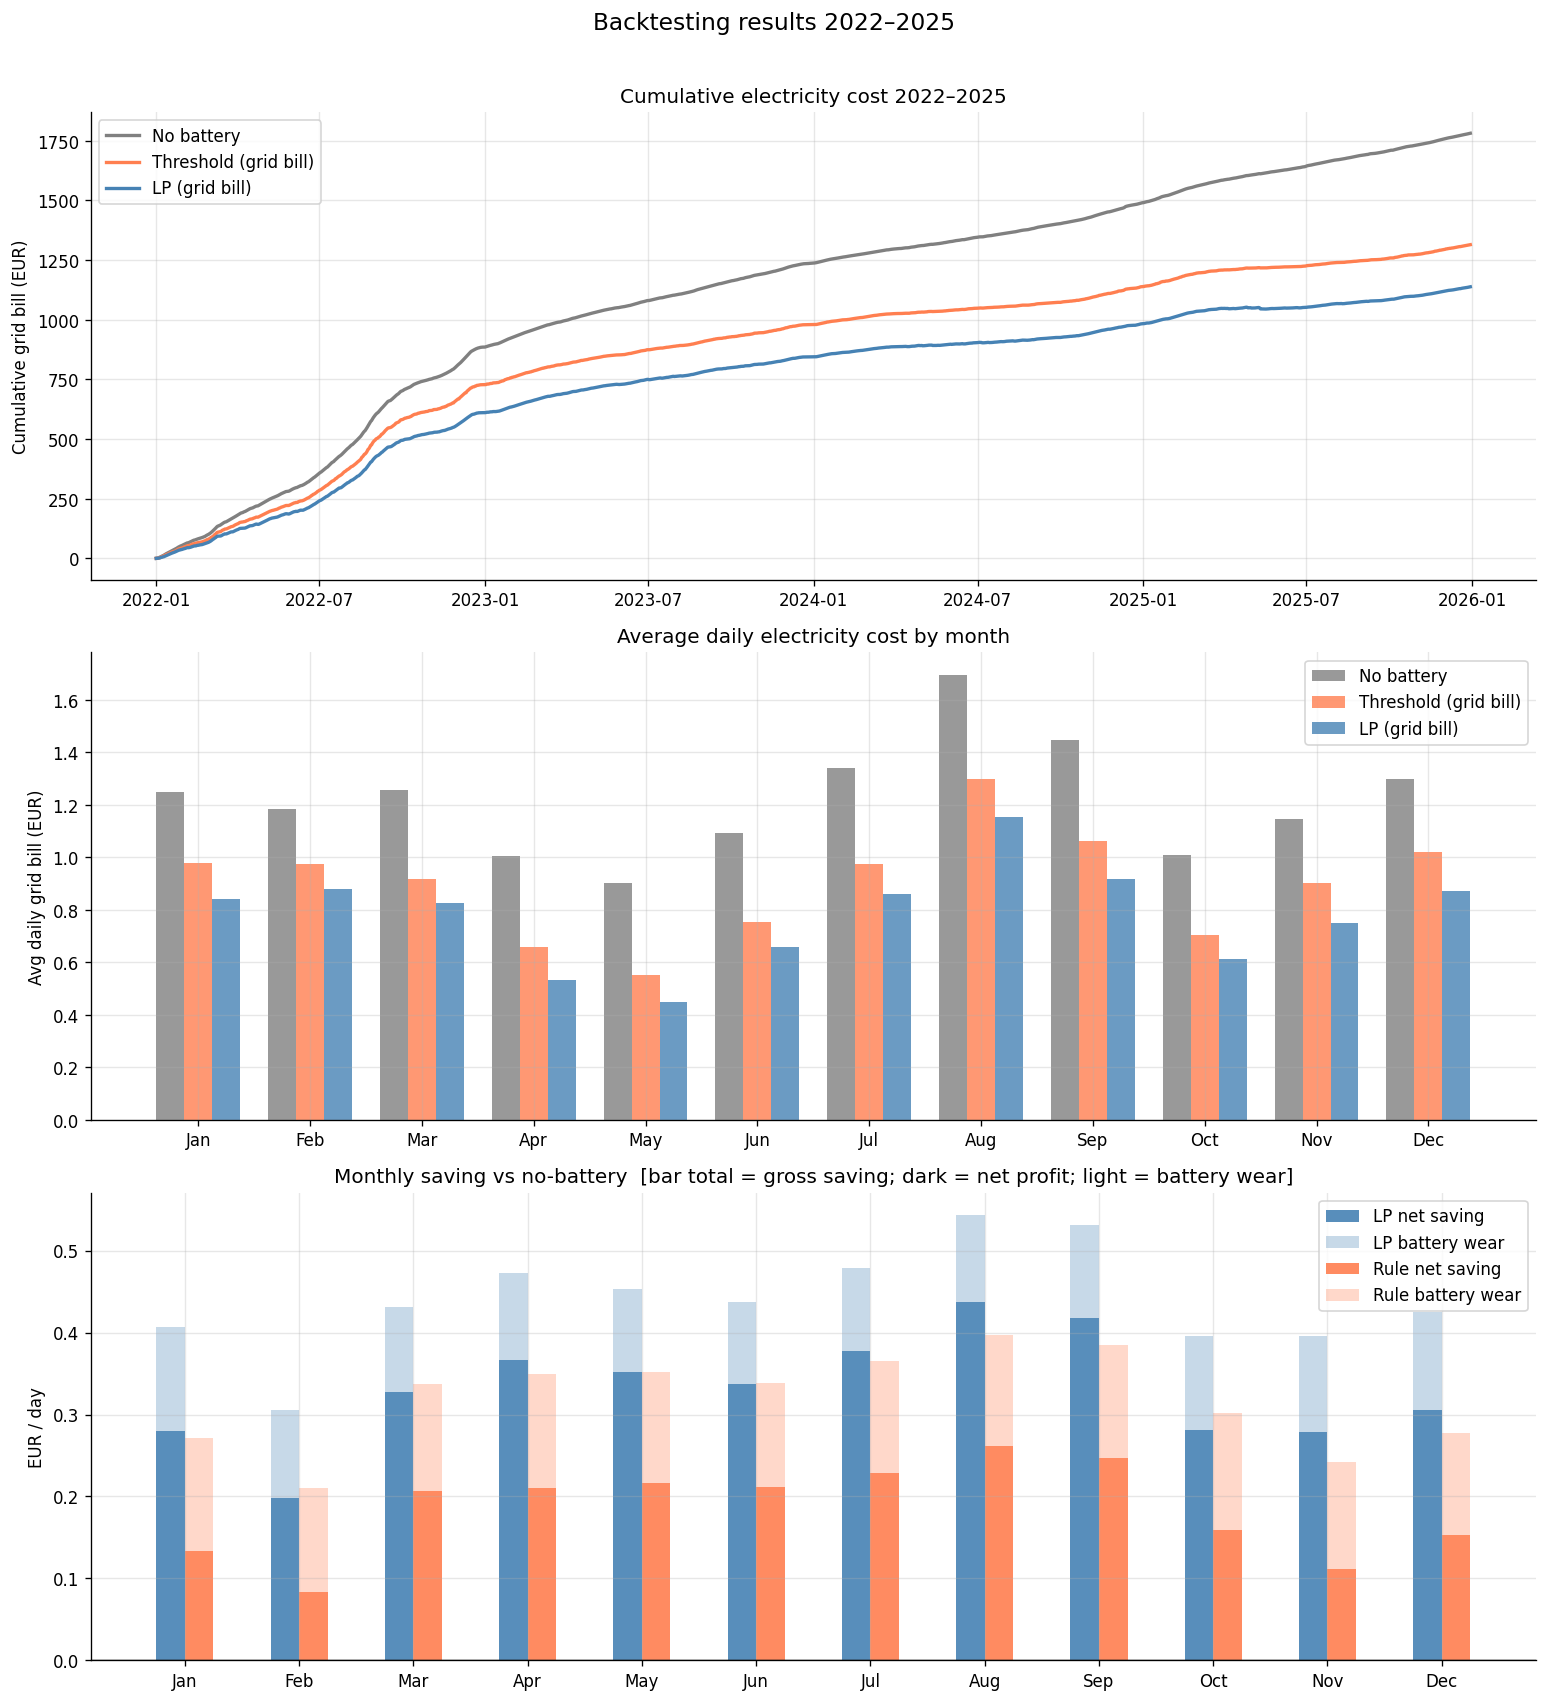

In [8]:
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(3, 1, figsize=(13, 14))

# ── Cumulative grid bill (electricity only, no degradation) ───────────────────
ax = axes[0]
ax.plot(pd.to_datetime(bt_lp.index),   bt_lp['cost_baseline'].cumsum(),     color='gray',      lw=2, label='No battery')
ax.plot(pd.to_datetime(bt_rule.index), bt_rule['cost_electricity'].cumsum(), color='coral',     lw=2, label='Threshold (grid bill)')
ax.plot(pd.to_datetime(bt_lp.index),   bt_lp['cost_electricity'].cumsum(),   color='steelblue', lw=2, label='LP (grid bill)')
ax.set_ylabel('Cumulative grid bill (EUR)')
ax.set_title('Cumulative electricity cost 2022–2025')
ax.legend()

# ── Average daily grid bill by month ──────────────────────────────────────────
ax2 = axes[1]
base_mo      = bt_lp.groupby('month')['cost_baseline'].mean()
lp_elec_mo   = bt_lp.groupby('month')['cost_electricity'].mean()
rule_elec_mo = bt_rule.groupby('month')['cost_electricity'].mean()
x = np.arange(1, 13)
w = 0.25
ax2.bar(x - w, base_mo.values,      width=w, color='gray',      alpha=0.8, label='No battery')
ax2.bar(x,     rule_elec_mo.values, width=w, color='coral',     alpha=0.8, label='Threshold (grid bill)')
ax2.bar(x + w, lp_elec_mo.values,   width=w, color='steelblue', alpha=0.8, label='LP (grid bill)')
ax2.set_xticks(x)
ax2.set_xticklabels(MONTH_NAMES)
ax2.set_ylabel('Avg daily grid bill (EUR)')
ax2.set_title('Average daily electricity cost by month')
ax2.legend()

# ── Net saving by month: stacked bar (net saving + degradation = gross saving) ─
# Bottom layer = saving_net (real profit after battery wear)
# Top layer    = cost_degradation (battery wear that "eats" into gross saving)
# Total height = saving_electricity (how much less we paid the grid vs no battery)
ax3 = axes[2]
lp_net_mo   = bt_lp.groupby('month')['saving_net'].mean()
rule_net_mo = bt_rule.groupby('month')['saving_net'].mean()
lp_deg_mo   = bt_lp.groupby('month')['cost_degradation'].mean()
rule_deg_mo = bt_rule.groupby('month')['cost_degradation'].mean()

ax3.bar(x - w/2, lp_net_mo.values,   width=w, color='steelblue', alpha=0.9, label='LP net saving')
ax3.bar(x - w/2, lp_deg_mo.values,   width=w, color='steelblue', alpha=0.3,
        bottom=lp_net_mo.values, label='LP battery wear')
ax3.bar(x + w/2, rule_net_mo.values, width=w, color='coral',     alpha=0.9, label='Rule net saving')
ax3.bar(x + w/2, rule_deg_mo.values, width=w, color='coral',     alpha=0.3,
        bottom=rule_net_mo.values, label='Rule battery wear')
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(MONTH_NAMES)
ax3.set_ylabel('EUR / day')
ax3.set_title('Monthly saving vs no-battery  [bar total = gross saving; dark = net profit; light = battery wear]')
ax3.legend()

plt.suptitle('Backtesting results 2022–2025', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Sensitivity analysis

How do net savings change when we vary one battery parameter at a time?

- **S_max** — capacity (kWh): does a bigger battery always pay off?
- **S_min** — minimum SOC (%): how much does depth-of-discharge protection cost?
- **P_max** — power (kW): is there a point where more power stops helping?
- **S_max × P_max** — 2D table: these two interact (big battery + small power = bottleneck)

All runs use the **threshold strategy** (fast). Baseline values are marked with ★.

In [ ]:
import time
from pathlib import Path

RECOMPUTE  = True   # False → load saved results, True → rerun (slow)
SENS_DIR   = Path('../results/sensitivity')
SENS_DIR.mkdir(parents=True, exist_ok=True)

# ── Parameter ranges ───────────────────────────────────────────────────────────
s_max_vals = [5.0, 7.5, 10.0, 12.5, 15.0]
s_min_pcts = [0, 5, 10, 15, 20]
p_max_vals = [2.0, 3.0, 5.0, 7.0, 10.0]

if RECOMPUTE:
    t0 = time.time()

    # ── OAT: S_max ────────────────────────────────────────────────────────────
    lp_smax, rule_smax = [], []
    for s_max in s_max_vals:
        kw = dict(S_init=0.5*s_max, deg_cost=DEG, S_min=0.1*s_max)
        lp_smax.append(
            backtest(prices, load, s_max, P_MAX, ETA_C, ETA_D,
                     strategy='lp', binary=False, **kw)['saving_net'].sum())
        rule_smax.append(
            backtest(prices, load, s_max, P_MAX, ETA_C, ETA_D,
                     strategy='threshold', **kw)['saving_net'].sum())
    print(f"S_max done  ({time.time()-t0:.1f}s)")

    # ── OAT: S_min ────────────────────────────────────────────────────────────
    lp_smin, rule_smin = [], []
    for pct in s_min_pcts:
        kw = dict(S_init=S_INIT, deg_cost=DEG, S_min=pct/100*S_MAX)
        lp_smin.append(
            backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D,
                     strategy='lp', binary=False, **kw)['saving_net'].sum())
        rule_smin.append(
            backtest(prices, load, S_MAX, P_MAX, ETA_C, ETA_D,
                     strategy='threshold', **kw)['saving_net'].sum())
    print(f"S_min done  ({time.time()-t0:.1f}s)")

    # ── OAT: P_max ────────────────────────────────────────────────────────────
    lp_pmax, rule_pmax = [], []
    for p_max in p_max_vals:
        kw = dict(S_init=S_INIT, deg_cost=DEG, S_min=S_MIN)
        lp_pmax.append(
            backtest(prices, load, S_MAX, p_max, ETA_C, ETA_D,
                     strategy='lp', binary=False, **kw)['saving_net'].sum())
        rule_pmax.append(
            backtest(prices, load, S_MAX, p_max, ETA_C, ETA_D,
                     strategy='threshold', **kw)['saving_net'].sum())
    print(f"P_max done  ({time.time()-t0:.1f}s)")

    # ── 2D grid: S_max × P_max (threshold only) ───────────────────────────────
    grid = np.zeros((len(s_max_vals), len(p_max_vals)))
    for i, s_max in enumerate(s_max_vals):
        for j, p_max in enumerate(p_max_vals):
            bt = backtest(prices, load, s_max, p_max, ETA_C, ETA_D,
                          S_init=0.5*s_max, strategy='threshold',
                          deg_cost=DEG, S_min=0.1*s_max)
            grid[i, j] = bt['saving_net'].sum()
    print(f"Grid done   ({time.time()-t0:.1f}s)")

    # ── Save results ──────────────────────────────────────────────────────────
    pd.DataFrame({'s_max': s_max_vals, 'lp': lp_smax, 'threshold': rule_smax}
                 ).to_csv(SENS_DIR / 'oat_smax.csv', index=False)
    pd.DataFrame({'s_min_pct': s_min_pcts, 'lp': lp_smin, 'threshold': rule_smin}
                 ).to_csv(SENS_DIR / 'oat_smin.csv', index=False)
    pd.DataFrame({'p_max': p_max_vals, 'lp': lp_pmax, 'threshold': rule_pmax}
                 ).to_csv(SENS_DIR / 'oat_pmax.csv', index=False)
    pd.DataFrame(grid, index=s_max_vals, columns=p_max_vals
                 ).to_csv(SENS_DIR / 'grid_smax_pmax.csv')
    print(f"Results saved to {SENS_DIR.resolve()}")

else:
    # ── Load saved results ────────────────────────────────────────────────────
    df_smax = pd.read_csv(SENS_DIR / 'oat_smax.csv')
    df_smin = pd.read_csv(SENS_DIR / 'oat_smin.csv')
    df_pmax = pd.read_csv(SENS_DIR / 'oat_pmax.csv')
    df_grid = pd.read_csv(SENS_DIR / 'grid_smax_pmax.csv', index_col=0)

    s_max_vals = df_smax['s_max'].tolist()
    lp_smax, rule_smax = df_smax['lp'].tolist(), df_smax['threshold'].tolist()

    s_min_pcts = df_smin['s_min_pct'].tolist()
    lp_smin, rule_smin = df_smin['lp'].tolist(), df_smin['threshold'].tolist()

    p_max_vals = df_pmax['p_max'].tolist()
    lp_pmax, rule_pmax = df_pmax['lp'].tolist(), df_pmax['threshold'].tolist()

    grid = df_grid.values
    print("Results loaded from files.")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def oat_plot(ax, xs, lp_vals, rule_vals, baseline_x, xlabel, title):
    ax.plot(xs, lp_vals,   marker='o', color='steelblue', lw=2, label='LP (optimal)')
    ax.plot(xs, rule_vals, marker='s', color='coral',     lw=2, ls='--', label='Threshold (rule)')
    ax.axvline(baseline_x, color='red', lw=1, ls=':', alpha=0.6, label='Baseline ★')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Net saving 2022–2025 (EUR)')
    ax.set_title(title)
    ax.legend()

oat_plot(axes[0, 0], s_max_vals, lp_smax, rule_smax, S_MAX,
         'Battery capacity S_max (kWh)', 'Effect of battery capacity')
oat_plot(axes[0, 1], s_min_pcts, lp_smin, rule_smin, S_MIN/S_MAX*100,
         'Minimum SOC S_min (% of capacity)', 'Effect of minimum SOC constraint')
oat_plot(axes[1, 0], p_max_vals, lp_pmax, rule_pmax, P_MAX,
         'Max charge/discharge power P_max (kW)', 'Effect of max power')

ax = axes[1, 1]
im = ax.imshow(grid, aspect='auto', cmap='YlGn', origin='lower')
ax.set_xticks(range(len(p_max_vals)))
ax.set_xticklabels([f'{v:.0f}' for v in p_max_vals])
ax.set_yticks(range(len(s_max_vals)))
ax.set_yticklabels([f'{v:.1f}' for v in s_max_vals])
ax.set_xlabel('P_max (kW)')
ax.set_ylabel('S_max (kWh)')
ax.set_title('Net saving (EUR) — S_max × P_max  [threshold]')
bi, bj = s_max_vals.index(S_MAX), p_max_vals.index(P_MAX)
ax.add_patch(plt.Rectangle((bj-0.5, bi-0.5), 1, 1,
             fill=False, edgecolor='red', lw=2, label='Baseline ★'))
plt.colorbar(im, ax=ax, label='EUR')
ax.legend(loc='upper left')
for i in range(len(s_max_vals)):
    for j in range(len(p_max_vals)):
        ax.text(j, i, f'{grid[i,j]:.0f}', ha='center', va='center', fontsize=8)

plt.suptitle('Sensitivity analysis — net saving 2022–2025', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Payback analysis

How many years until the battery pays for itself?

**Assumptions for the 10-year projection:**
- Base annual saving = average over the 4-year backtest (2022–2025)
- `saving_net` already includes per-cycle degradation cost (`deg_cost`) — no double-counting
- **Capacity degradation** (~2.5%/yr LFP): battery gradually stores less → proportionally lower savings
- **Electricity price growth** (~3%/yr): higher future prices → proportionally higher savings
- Both effects are applied as multipliers on the base saving each year

Price scale factor: ×1.21  (VAT 21%)
Average annual net saving — LP:            146 EUR/year  (incl. VAT)
Average annual net saving — Threshold:      82 EUR/year  (incl. VAT)
Simple payback — LP:        27.4 years
Simple payback — Threshold: 48.7 years

10-year projection  [inflation 3%/yr | capacity loss 2.5%/yr | VAT 21%]
      LP saving (EUR)  LP cumulative (EUR)  Rule saving (EUR)  Rule cumulative (EUR)
year                                                                                
1                 147                  147                 82                     82
2                 147                  294                 83                    165
3                 148                  441                 83                    248
4                 148                  589                 83                    332
5                 148                  737                 83                    415
6                 148                  886                 83                  

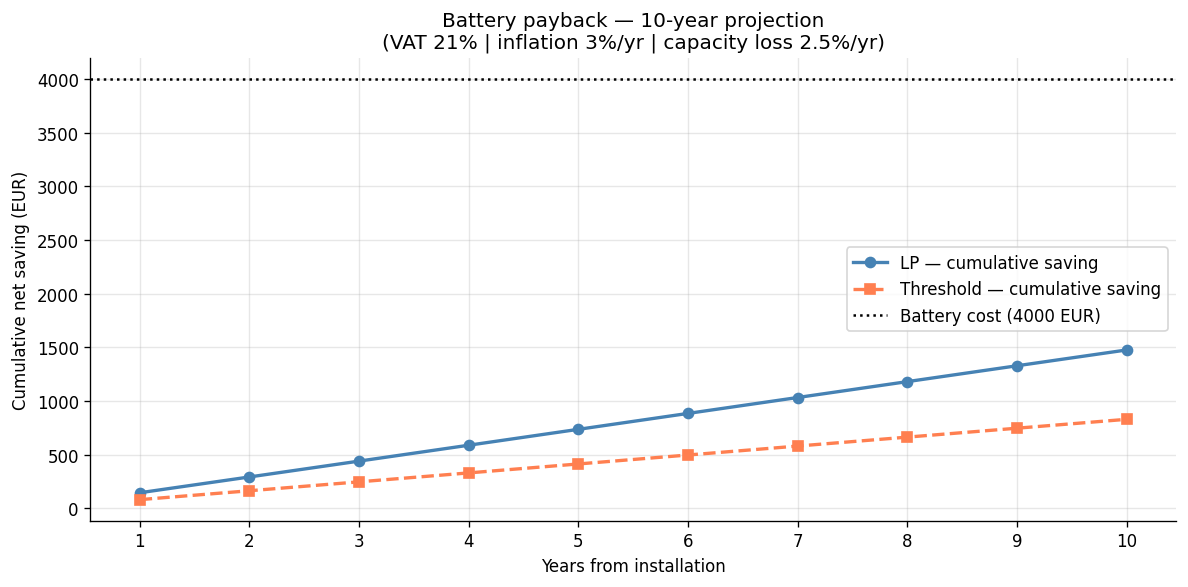

In [9]:
# ── Investment & price parameters ────────────────────────────────────────────
BATTERY_COST         = 4000   # EUR — installed cost (battery + inverter + installation)
PROJECTION_YEARS     = 10     # years to project forward
PRICE_INFLATION      = 0.03   # 3%/yr — electricity price growth (Belgian historical avg)
CAPACITY_DEGRADATION = 0.025  # 2.5%/yr — LFP capacity loss (≈20-25% over 10 years)

# Model uses raw EPEX spot prices. Real consumer price = spot + markup + VAT + levies.
# Fixed markup (DSO grid fee, supplier margin) cancels out in saving_net (paid with and without battery).
# VAT (21%) and price-proportional levies DO scale savings — apply as a multiplier here.
VAT                = 0.21   # Belgian VAT on electricity
PRICE_SCALE_FACTOR = 1 + VAT  # effective saving multiplier (extend if other % levies apply)

# ── Base annual saving from backtest (scaled to effective consumer price) ─────
n_years  = bt_lp['year'].nunique()
avg_lp   = bt_lp['saving_net'].sum()   / n_years * PRICE_SCALE_FACTOR
avg_rule = bt_rule['saving_net'].sum() / n_years * PRICE_SCALE_FACTOR

print(f"Price scale factor: ×{PRICE_SCALE_FACTOR:.2f}  (VAT {VAT*100:.0f}%)")
print(f"Average annual net saving — LP:        {avg_lp:7.0f} EUR/year  (incl. VAT)")
print(f"Average annual net saving — Threshold: {avg_rule:7.0f} EUR/year  (incl. VAT)")
print(f"Simple payback — LP:        {BATTERY_COST / avg_lp:.1f} years")
print(f"Simple payback — Threshold: {BATTERY_COST / avg_rule:.1f} years")

# ── Year-by-year projection ───────────────────────────────────────────────────
# saving_year_n = base × capacity_factor × price_factor
# capacity_factor = 1 - CAPACITY_DEGRADATION × n   (linear capacity loss)
# price_factor    = (1 + PRICE_INFLATION) ^ n       (compound price growth)
years       = list(range(1, PROJECTION_YEARS + 1))
lp_annual, rule_annual = [], []

for n in years:
    cap_factor   = max(0, 1 - CAPACITY_DEGRADATION * n)
    price_factor = (1 + PRICE_INFLATION) ** n
    lp_annual.append(avg_lp   * cap_factor * price_factor)
    rule_annual.append(avg_rule * cap_factor * price_factor)

lp_cumul   = [sum(lp_annual[:i+1])   for i in range(PROJECTION_YEARS)]
rule_cumul = [sum(rule_annual[:i+1]) for i in range(PROJECTION_YEARS)]

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for i, n in enumerate(years):
    rows.append({
        'year':                  n,
        'LP saving (EUR)':       round(lp_annual[i]),
        'LP cumulative (EUR)':   round(lp_cumul[i]),
        'Rule saving (EUR)':     round(rule_annual[i]),
        'Rule cumulative (EUR)': round(rule_cumul[i]),
    })
proj_df = pd.DataFrame(rows).set_index('year')
print(f"\n{PROJECTION_YEARS}-year projection  "
      f"[inflation {PRICE_INFLATION*100:.0f}%/yr | capacity loss {CAPACITY_DEGRADATION*100:.1f}%/yr | VAT {VAT*100:.0f}%]")
print(proj_df.to_string())

# ── Payback year ──────────────────────────────────────────────────────────────
def payback_year(cumul, cost):
    for i, c in enumerate(cumul):
        if c >= cost:
            return i + 1
    return None

pb_lp   = payback_year(lp_cumul,   BATTERY_COST)
pb_rule = payback_year(rule_cumul, BATTERY_COST)

print(f"\nBattery cost: {BATTERY_COST} EUR")
print(f"Payback LP:        {'year ' + str(pb_lp) if pb_lp else 'not reached in ' + str(PROJECTION_YEARS) + ' years'}")
print(f"Payback Threshold: {'year ' + str(pb_rule) if pb_rule else 'not reached in ' + str(PROJECTION_YEARS) + ' years'}")
print(f"10-year net gain LP:        {lp_cumul[-1] - BATTERY_COST:+.0f} EUR")
print(f"10-year net gain Threshold: {rule_cumul[-1] - BATTERY_COST:+.0f} EUR")

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(years, lp_cumul,   marker='o', color='steelblue', lw=2, label='LP — cumulative saving')
ax.plot(years, rule_cumul, marker='s', color='coral',     lw=2, ls='--', label='Threshold — cumulative saving')
ax.axhline(BATTERY_COST, color='black', lw=1.5, ls=':', label=f'Battery cost ({BATTERY_COST} EUR)')

if pb_lp:
    ax.axvline(pb_lp,   color='steelblue', lw=1, ls='--', alpha=0.5)
if pb_rule:
    ax.axvline(pb_rule, color='coral',     lw=1, ls='--', alpha=0.5)

ax.set_xlabel('Years from installation')
ax.set_ylabel('Cumulative net saving (EUR)')
ax.set_title(f'Battery payback — {PROJECTION_YEARS}-year projection\n'
             f'(VAT {VAT*100:.0f}% | inflation {PRICE_INFLATION*100:.0f}%/yr | '
             f'capacity loss {CAPACITY_DEGRADATION*100:.1f}%/yr)')
ax.set_xticks(years)
ax.legend()
plt.tight_layout()
plt.show()

### 7b. Crisis year vs normal market

2022 was an exceptional year (energy crisis → extreme price volatility → high arbitrage savings).  
This cell separates the **crisis year** from the **normal market** (2023–2025) to show
how much the payback estimate depends on which period you use as a baseline.

In [ ]:
# ── Split backtest into crisis year vs normal market ──────────────────────────
CRISIS_YEAR  = 2022
normal_years = [y for y in bt_lp['year'].unique() if y != CRISIS_YEAR]

bt_crisis = bt_lp[bt_lp['year'] == CRISIS_YEAR]
bt_normal = bt_lp[bt_lp['year'].isin(normal_years)]

# Annual averages for each period (LP strategy, scaled with VAT)
avg_crisis = bt_crisis['saving_net'].sum() * PRICE_SCALE_FACTOR          # only 1 year
avg_normal = bt_normal['saving_net'].sum() / len(normal_years) * PRICE_SCALE_FACTOR

print(f"Crisis year ({CRISIS_YEAR}):    {avg_crisis:6.0f} EUR/year  (incl. VAT {VAT*100:.0f}%)")
print(f"Normal years {normal_years}: {avg_normal:6.0f} EUR/year  (incl. VAT {VAT*100:.0f}%)")
print(f"Full period average:         {avg_lp:6.0f} EUR/year")
print()
print(f"Simple payback — crisis year as baseline:  {BATTERY_COST / avg_crisis:.1f} years")
print(f"Simple payback — normal market as baseline: {BATTERY_COST / avg_normal:.1f} years")
print(f"Simple payback — full 4-yr average:         {BATTERY_COST / avg_lp:.1f} years")

# ── 10-year projection for both scenarios ─────────────────────────────────────
proj_years = list(range(1, PROJECTION_YEARS + 1))
cumul_crisis, cumul_normal = [], []

for n in proj_years:
    cap_factor   = max(0, 1 - CAPACITY_DEGRADATION * n)
    price_factor = (1 + PRICE_INFLATION) ** n
    cumul_crisis.append(sum(avg_crisis * max(0, 1 - CAPACITY_DEGRADATION * k) * (1 + PRICE_INFLATION)**k
                            for k in range(1, n + 1)))
    cumul_normal.append(sum(avg_normal * max(0, 1 - CAPACITY_DEGRADATION * k) * (1 + PRICE_INFLATION)**k
                            for k in range(1, n + 1)))

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(proj_years, lp_cumul,      marker='o', color='steelblue', lw=2,      label=f'Full avg 2022–2025 ({avg_lp:.0f} EUR/yr)')
ax.plot(proj_years, cumul_crisis,  marker='^', color='orange',    lw=2,      label=f'Crisis year {CRISIS_YEAR} ({avg_crisis:.0f} EUR/yr)')
ax.plot(proj_years, cumul_normal,  marker='s', color='coral',     lw=2, ls='--', label=f'Normal market {normal_years[0]}–{normal_years[-1]} ({avg_normal:.0f} EUR/yr)')
ax.axhline(BATTERY_COST, color='black', lw=1.5, ls=':', label=f'Battery cost ({BATTERY_COST} EUR)')

ax.set_xlabel('Years from installation')
ax.set_ylabel('Cumulative net saving (EUR)')
ax.set_title(f'Payback sensitivity — crisis year vs normal market\n'
             f'(VAT {VAT*100:.0f}% | inflation {PRICE_INFLATION*100:.0f}%/yr | capacity loss {CAPACITY_DEGRADATION*100:.1f}%/yr)')
ax.set_xticks(proj_years)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Best & worst days

Which days did the battery save the most / least?
Key driver: `price_range` = max − min price within a day — the wider the spread, the more the battery can earn.

── Top 10 best days (LP net saving) ─────────────────────────
             weekday  season  price_range  price_mean  cost_baseline  saving_net saving_%
date                                                                                     
2025-05-11    Sunday  Spring        0.589      -0.010          -0.48        3.94        —
2025-04-27    Sunday  Spring        0.391       0.029           0.05        2.30        —
2022-08-28    Sunday  Summer        0.680       0.408           3.85        1.99    51.8%
2022-07-25    Monday  Summer        0.241       0.295           2.94        1.99    67.6%
2022-03-08   Tuesday  Spring        0.545       0.462           4.30        1.97    45.8%
2022-08-13  Saturday  Summer        0.485       0.362           3.75        1.89    50.4%
2022-03-14    Monday  Spring        0.232       0.280           2.66        1.77    66.8%
2022-07-24    Sunday  Summer        0.483       0.239           2.12        1.75    82.4%
2022-12-13   Tuesday  Winter        0.

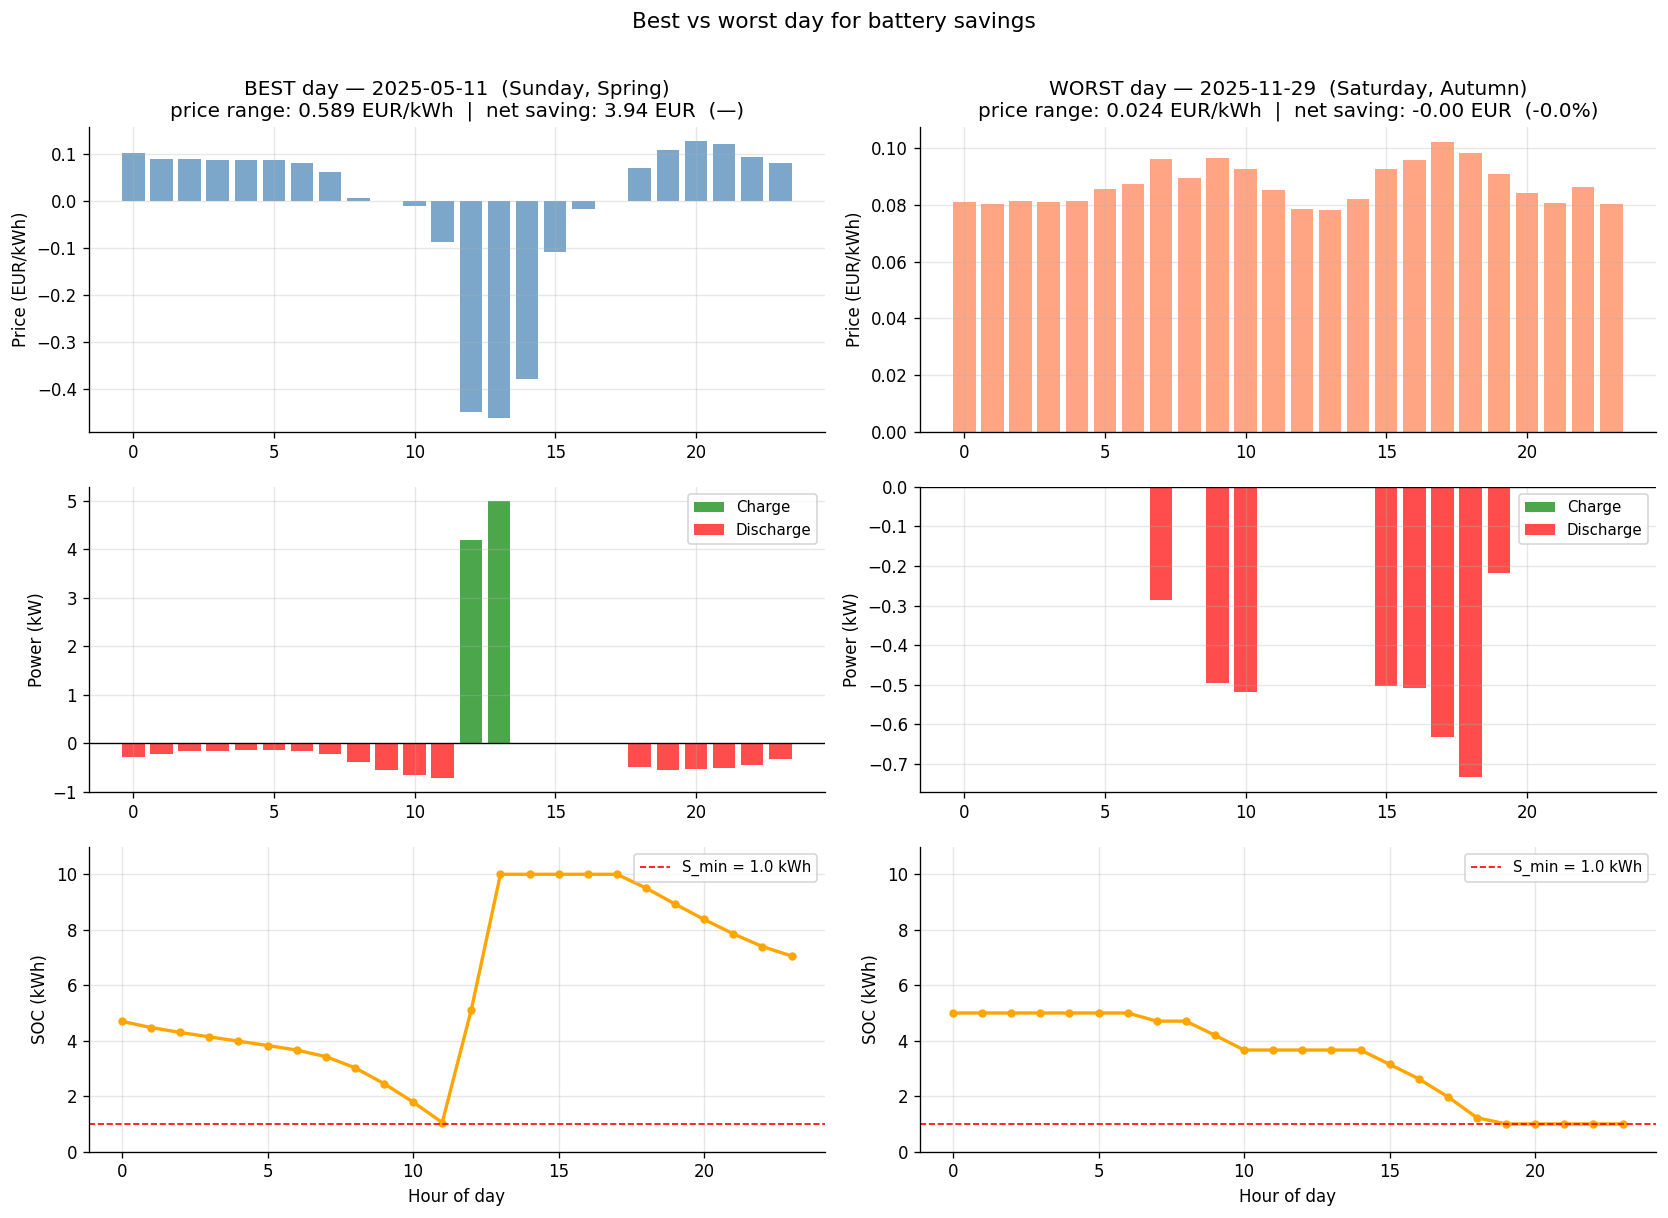

In [10]:
# ── Daily price statistics ────────────────────────────────────────────────────
prices_naive = prices.copy()
prices_naive.index = prices_naive.index.tz_localize(None)
p_stats = (prices_naive['price_eur_kwh']
           .groupby(prices_naive.index.date)
           .agg(price_min='min', price_max='max', price_mean='mean'))
p_stats['price_range'] = p_stats['price_max'] - p_stats['price_min']
p_stats.index = pd.to_datetime(p_stats.index)

# ── Enrich bt_lp with price stats and calendar info ───────────────────────────
def season(month):
    return {12:'Winter',1:'Winter',2:'Winter',
            3:'Spring',4:'Spring',5:'Spring',
            6:'Summer',7:'Summer',8:'Summer'}.get(month, 'Autumn')

bt = bt_lp.copy()
bt.index = pd.to_datetime(bt.index)
bt = bt.join(p_stats)
bt['weekday'] = bt.index.day_name()
bt['season']  = bt.index.month.map(season)

# saving_% is only meaningful when baseline cost is clearly positive
# (negative or near-zero baseline → extreme %, e.g. on negative-price days)
MIN_BASELINE = 0.05  # EUR — below this threshold saving_% is not shown
bt['saving_%'] = bt.apply(
    lambda r: f"{r['saving_net'] / r['cost_baseline'] * 100:.1f}%"
              if r['cost_baseline'] > MIN_BASELINE else '—',
    axis=1
)

COLS = ['weekday', 'season', 'price_range', 'price_mean',
        'cost_baseline', 'saving_net', 'saving_%']

def fmt(df):
    df = df.copy()
    df['price_range']   = df['price_range'].round(3)
    df['price_mean']    = df['price_mean'].round(3)
    df['cost_baseline'] = df['cost_baseline'].round(2)
    df['saving_net']    = df['saving_net'].round(2)
    return df

# ── Top 10 best days ──────────────────────────────────────────────────────────
top10 = fmt(bt.nlargest(10, 'saving_net')[COLS])
print("── Top 10 best days (LP net saving) ─────────────────────────")
print(top10.to_string())

# ── Top 10 worst days ─────────────────────────────────────────────────────────
bot10 = fmt(bt.nsmallest(10, 'saving_net')[COLS])
print("\n── Top 10 worst days (LP net saving) ────────────────────────")
print(bot10.to_string())

# ── Price profile comparison: best vs worst day ───────────────────────────────
best_date  = bt['saving_net'].idxmax()
worst_date = bt['saving_net'].idxmin()

def day_data(date):
    p = prices[prices.index.date == date.date()]['price_eur_kwh'].values
    l = load[load.index.date == date.date()]['consumption'].values
    res = optimize_day(p, l, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                       cyclic=False, binary=True, deg_cost=DEG, S_min=S_MIN)
    return p, l, res

p_best,  l_best,  res_best  = day_data(best_date)
p_worst, l_worst, res_worst = day_data(worst_date)

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False)

for col, (date, p, res, label) in enumerate([
    (best_date,  p_best,  res_best,  'BEST'),
    (worst_date, p_worst, res_worst, 'WORST'),
]):
    saving    = bt.loc[date, 'saving_net']
    price_rng = bt.loc[date, 'price_range']
    pct       = bt.loc[date, 'saving_%']
    hours     = range(len(p))
    color     = 'steelblue' if col == 0 else 'coral'

    axes[0, col].bar(hours, p, color=color, alpha=0.7)
    axes[0, col].set_ylabel('Price (EUR/kWh)')
    axes[0, col].set_title(
        f'{label} day — {date.date()}  ({bt.loc[date,"weekday"]}, {bt.loc[date,"season"]})\n'
        f'price range: {price_rng:.3f} EUR/kWh  |  net saving: {saving:.2f} EUR  ({pct})')

    axes[1, col].bar(hours, res['c'], color='green', alpha=0.7, label='Charge')
    axes[1, col].bar(hours, [-x for x in res['d']], color='red', alpha=0.7, label='Discharge')
    axes[1, col].axhline(0, color='black', lw=0.8)
    axes[1, col].set_ylabel('Power (kW)')
    axes[1, col].legend(fontsize=9)

    axes[2, col].plot(hours, res['s'], color='orange', lw=2, marker='o', ms=4)
    axes[2, col].axhline(S_MIN, color='red', lw=1, ls='--', label=f'S_min = {S_MIN} kWh')
    axes[2, col].set_ylabel('SOC (kWh)')
    axes[2, col].set_xlabel('Hour of day')
    axes[2, col].set_ylim(0, S_MAX + 1)
    axes[2, col].legend(fontsize=9)

plt.suptitle('Best vs worst day for battery savings', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()